# INTELLIGENT SYSTEM DEVELOPMENT - ASSIGNMENT 03

## Ứng dụng 1: Diabetes Classification

**Dataset:** CDC Diabetes Health Indicators / BRFSS 2015  
**Target:** `Diabetes_binary`  
**Bài toán:** Binary Classification  
**Mục tiêu:** Dự đoán nhóm có nguy cơ tiền tiểu đường/tiểu đường từ các chỉ báo sức khỏe khảo sát.

---

### 1. Định nghĩa bài toán

- **Đầu vào:** 21 health indicators dạng numeric-coded.
- **Đầu ra:** xác suất và nhãn nhị phân `0/1`.
- **Đánh giá:** so sánh 5 mô hình ML với Improved DNN. DL baseline của giảng viên được trình bày riêng.


---

### 2. Thiết lập môi trường

Import thư viện, xác định project root và khai báo helper cho EDA/preprocessing.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import joblib
import math
import re
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:

    def display(obj=None):
        if obj is not None:
            print(obj)


try:
    import matplotlib.pyplot as plt

    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False

    class _NoPlotAxis:
        def __getattr__(self, name):
            def _method(*args, **kwargs):
                return self

            return _method

    class _NoPlotAxes(list):
        def ravel(self):
            return self

    class _NoPlot:
        def figure(self, *args, **kwargs):
            print("Matplotlib is not installed; plot skipped.")
            return _NoPlotAxis()

        def subplots(self, nrows=1, ncols=1, *args, **kwargs):
            print("Matplotlib is not installed; plot skipped.")
            fig = _NoPlotAxis()
            if nrows == 1 and ncols == 1:
                return fig, _NoPlotAxis()
            axes = _NoPlotAxes([_NoPlotAxis() for _ in range(nrows * ncols)])
            return fig, axes

        def __getattr__(self, name):
            def _method(*args, **kwargs):
                return _NoPlotAxis()

            return _method

    plt = _NoPlot()

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "datasets").exists() and (candidate / "pipeline").exists():
            return candidate
    return start


ROOT = find_project_root()
DATA_DIR = ROOT / "datasets"
ARTIFACT_DIR = ROOT / "artifacts"

print("Project root:", ROOT)


def display_df(title, df, rows=10):
    print(title)
    display(df.head(rows))


def missing_table(df):
    result = pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_pct": df.isna().mean().mul(100).round(2),
            "dtype": df.dtypes.astype(str),
            "n_unique": df.nunique(dropna=True),
        }
    )
    return result.sort_values(["missing_pct", "missing_count"], ascending=False)


def iqr_outlier_table(df, columns):
    rows = []
    for col in columns:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        rows.append(
            {
                "feature": col,
                "min": s.min(),
                "q1": q1,
                "median": s.median(),
                "q3": q3,
                "max": s.max(),
                "iqr_lower": lo,
                "iqr_upper": hi,
                "outlier_count": int(((s < lo) | (s > hi)).sum()),
                "outlier_pct": round(((s < lo) | (s > hi)).mean() * 100, 2),
            }
        )
    return pd.DataFrame(rows)


def make_one_hot_encoder(**kwargs):
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, **kwargs)
    except TypeError:
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse=True, **kwargs)
        except TypeError:
            legacy_kwargs = {
                k: v
                for k, v in kwargs.items()
                if k not in {"min_frequency", "max_categories"}
            }
            return OneHotEncoder(handle_unknown="ignore", sparse=True, **legacy_kwargs)


def to_dense_array(matrix):
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def dense_transformer():
    return FunctionTransformer(to_dense_array, accept_sparse=True, validate=False)


def assert_no_nan_inf(matrix, name):
    values = matrix.data if hasattr(matrix, "data") else np.asarray(matrix)
    assert np.isfinite(values).all(), f"{name} contains NaN or Inf"
    print(f"{name}: shape={matrix.shape}, finite_values=OK")

Project root: c:\DATA\assign


---

### 3. Nạp dữ liệu

Nạp dataset CDC Diabetes Health Indicators và xác định target `Diabetes_binary`.


In [2]:
DIABETES_PATH = DATA_DIR / "diabetes" / "diabetes.csv"
assert DIABETES_PATH.exists(), f"Missing dataset: {DIABETES_PATH}"

diabetes_raw = pd.read_csv(DIABETES_PATH)
DIABETES_TARGET = "Diabetes_binary"

print("Dataset path:", DIABETES_PATH)
print("Shape:", diabetes_raw.shape)
display(diabetes_raw.head())
display(diabetes_raw.dtypes.to_frame("dtype").T)

Dataset path: c:\DATA\assign\datasets\diabetes\diabetes.csv
Shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


**Nhận xét.** Dữ liệu gốc có 70,692 dòng và 22 cột, lớn hơn nhiều so với bộ Pima 768 dòng. Toàn bộ 21 feature đầu vào là numeric-coded nên phù hợp để so sánh ML tabular và NumPy DNN.


---

### 4. Cấu trúc feature

Phân loại feature theo vai trò: binary, ordinal, count và continuous.


In [3]:
BINARY_FEATURES = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
]
ORDINAL_FEATURES = ["GenHlth", "Age", "Education", "Income"]
COUNT_FEATURES = ["MentHlth", "PhysHlth"]
CONTINUOUS_FEATURES = ["BMI"]

DIABETES_FEATURES = [c for c in diabetes_raw.columns if c != DIABETES_TARGET]

role_rows = []
for col in DIABETES_FEATURES:
    if col in BINARY_FEATURES:
        role = "binary indicator"
    elif col in ORDINAL_FEATURES:
        role = "ordinal survey code"
    elif col in COUNT_FEATURES:
        role = "days in last 30 days"
    elif col in CONTINUOUS_FEATURES:
        role = "continuous numeric"
    else:
        role = "numeric-coded"
    role_rows.append(
        {"column": col, "role": role, "n_unique": diabetes_raw[col].nunique()}
    )

diabetes_roles = pd.DataFrame(role_rows)
display(diabetes_roles)

,column,role,n_unique
0,HighBP,binary indicator,2
1,HighChol,binary indicator,2
2,CholCheck,binary indicator,2
3,BMI,continuous numeric,80
4,Smoker,binary indicator,2
5,Stroke,binary indicator,2
6,HeartDiseaseorAttack,binary indicator,2
7,PhysActivity,binary indicator,2
8,Fruits,binary indicator,2
9,Veggies,binary indicator,2


**Nhận xét.** Có 14 binary indicators, 4 ordinal features, 2 count features và 1 continuous feature (`BMI`). Cấu trúc này cho thấy không thể đọc mọi cột như biến liên tục thông thường.


---

### 5. Kiểm tra chất lượng dữ liệu

Kiểm tra missing values, duplicates, invalid ranges và zero values.


In [4]:
display(missing_table(diabetes_raw))

duplicate_count = int(diabetes_raw.duplicated().sum())
print("Duplicate rows:", duplicate_count)

expected_ranges = {
    **{col: (0, 1) for col in BINARY_FEATURES},
    "Diabetes_binary": (0, 1),
    "BMI": (1, 120),
    "GenHlth": (1, 5),
    "MentHlth": (0, 30),
    "PhysHlth": (0, 30),
    "Age": (1, 13),
    "Education": (1, 6),
    "Income": (1, 8),
}

invalid_rows = []
for col, (lo, hi) in expected_ranges.items():
    s = pd.to_numeric(diabetes_raw[col], errors="coerce")
    invalid_rows.append(
        {
            "column": col,
            "expected_range": f"[{lo}, {hi}]",
            "invalid_count": int(((s < lo) | (s > hi) | s.isna()).sum()),
            "zero_count": int((s == 0).sum()),
        }
    )

invalid_summary = pd.DataFrame(invalid_rows)
display(invalid_summary.sort_values("invalid_count", ascending=False))

,missing_count,missing_pct,dtype,n_unique
Diabetes_binary,0,0.0,float64,2
HighBP,0,0.0,float64,2
HighChol,0,0.0,float64,2
CholCheck,0,0.0,float64,2
BMI,0,0.0,float64,80
Smoker,0,0.0,float64,2
Stroke,0,0.0,float64,2
HeartDiseaseorAttack,0,0.0,float64,2
PhysActivity,0,0.0,float64,2
Fruits,0,0.0,float64,2


Duplicate rows: 1635


,column,expected_range,invalid_count,zero_count
0,HighBP,"[0, 1]",0,30860
1,HighChol,"[0, 1]",0,33529
2,CholCheck,"[0, 1]",0,1749
3,Smoker,"[0, 1]",0,37094
4,Stroke,"[0, 1]",0,66297
5,HeartDiseaseorAttack,"[0, 1]",0,60243
6,PhysActivity,"[0, 1]",0,20993
7,Fruits,"[0, 1]",0,27443
8,Veggies,"[0, 1]",0,14932
9,HvyAlcoholConsump,"[0, 1]",0,67672


**Nhận xét.** Missing values bằng 0, nhưng có 1,635 exact duplicates. Vì vậy duplicate được loại trước split, còn zero values được giữ khi nằm trong range hợp lệ.


---

### 6. Làm sạch dữ liệu

Ép kiểu số, chuyển target về `int` và bỏ duplicate.


In [5]:
diabetes = diabetes_raw.copy()
for col in diabetes.columns:
    diabetes[col] = pd.to_numeric(diabetes[col], errors="coerce")

before = len(diabetes)
diabetes = diabetes.drop_duplicates().reset_index(drop=True)
after = len(diabetes)
diabetes[DIABETES_TARGET] = diabetes[DIABETES_TARGET].astype(int)

print(f"Rows before duplicate removal: {before:,}")
print(f"Rows after duplicate removal:  {after:,}")
print(f"Removed duplicates:           {before - after:,}")

Rows before duplicate removal: 70,692
Rows after duplicate removal:  69,057
Removed duplicates:           1,635


**Nhận xét.** Sau cleaning còn 69,057 dòng. Dataset chỉ giảm 2.31%, nên việc bỏ duplicate không làm mất nhiều dữ liệu nhưng giảm nguy cơ cùng một vector xuất hiện ở train và test.


---

### 7. Phân tích target

Kiểm tra phân bố `Diabetes_binary` để chọn metric phù hợp.


,count,pct
Diabetes_binary,,
0,33960,49.18
1,35097,50.82


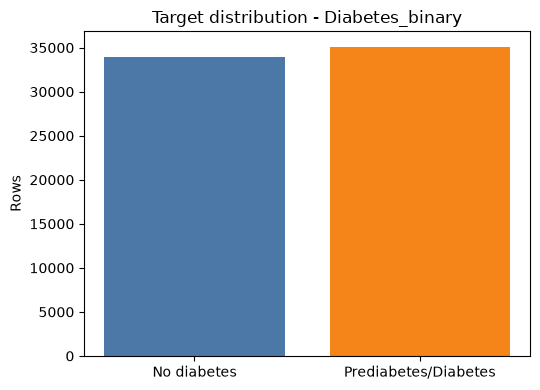

In [6]:
target_counts = diabetes[DIABETES_TARGET].value_counts().sort_index()
target_pct = (
    diabetes[DIABETES_TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
target_table = pd.DataFrame({"count": target_counts, "pct": target_pct})
display(target_table)

plt.figure(figsize=(5.5, 4))
plt.bar(
    ["No diabetes", "Prediabetes/Diabetes"],
    target_counts.values,
    color=["#4C78A8", "#F58518"],
)
plt.title("Target distribution - Diabetes_binary")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

**Nhận xét.** Sau cleaning, class `0` có 33,960 dòng (49.18%) và class `1` có 35,097 dòng (50.82%). Target gần cân bằng, nhưng F1/Recall/ROC-AUC vẫn cần thiết vì mục tiêu là phát hiện nhóm nguy cơ.


---

### 8. Phân phối feature

Quan sát phân bố các health indicators chính.


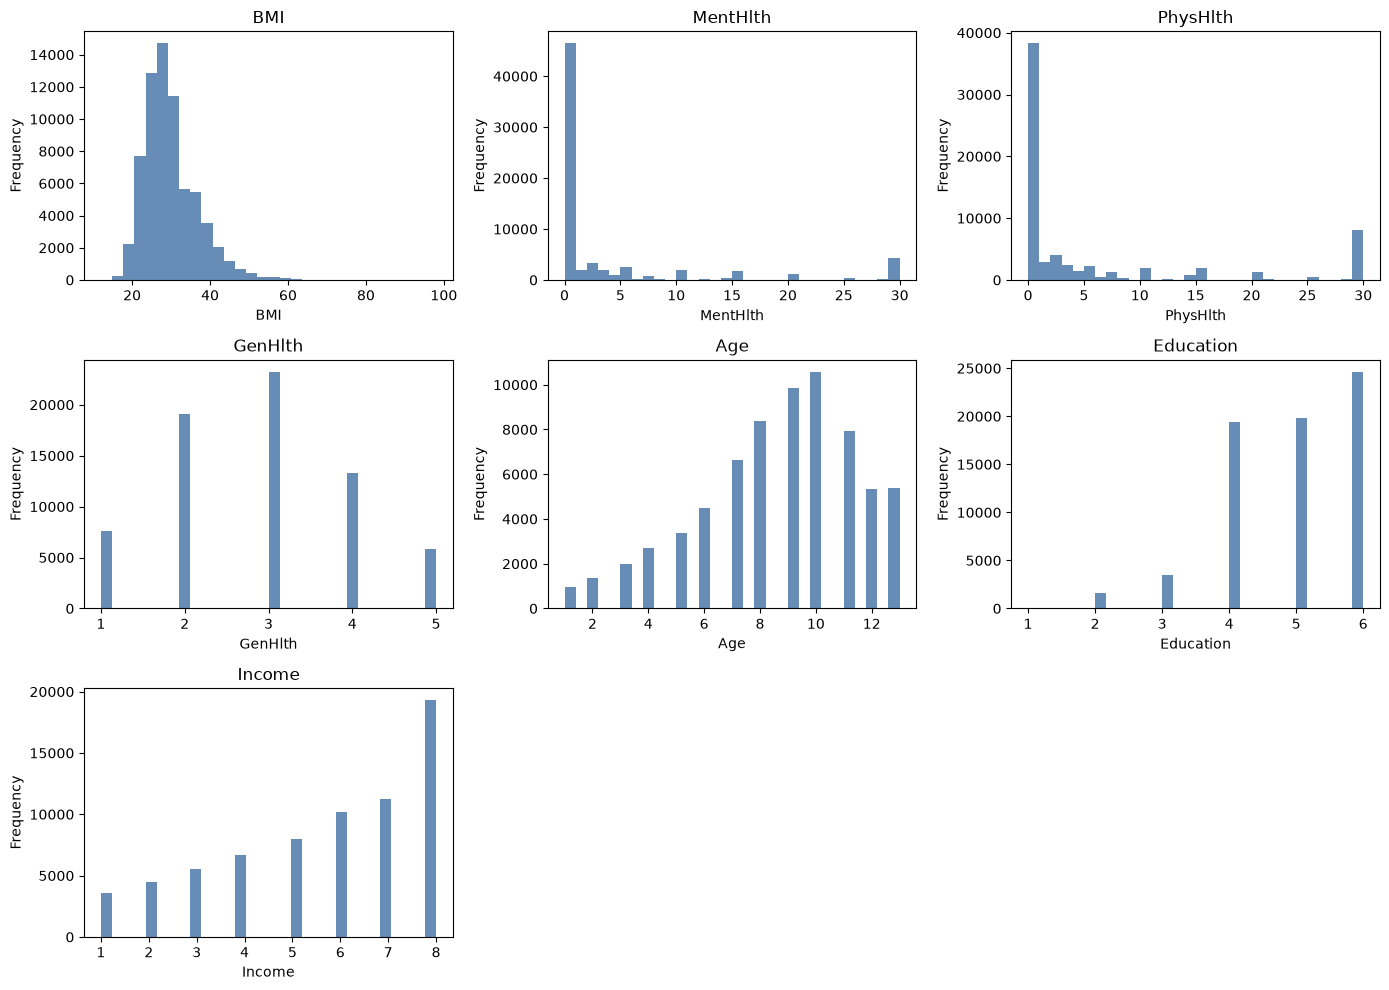

,count,mean,std,min,25%,50%,75%,max
BMI,69057.0,29.955834,7.147972,12.0,25.0,29.0,33.0,98.0
MentHlth,69057.0,3.840103,8.231164,0.0,0.0,0.0,3.0,30.0
PhysHlth,69057.0,5.945306,10.139113,0.0,0.0,0.0,6.0,30.0
GenHlth,69057.0,2.863692,1.107950,1.0,2.0,3.0,4.0,5.0
Age,69057.0,8.604037,2.858284,1.0,7.0,9.0,11.0,13.0
Education,69057.0,4.900285,1.029338,1.0,4.0,5.0,6.0,6.0
Income,69057.0,5.651332,2.175608,1.0,4.0,6.0,8.0,8.0


In [7]:
plot_cols = ["BMI", "MentHlth", "PhysHlth", "GenHlth", "Age", "Education", "Income"]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    ax.hist(diabetes[col].dropna(), bins=30, color="#4C78A8", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
for ax in axes[len(plot_cols) :]:
    ax.axis("off")
plt.tight_layout()
plt.show()

display(diabetes[plot_cols].describe().T)

**Nhận xét.** `BMI` có median 29.0, mean 29.96 và max 98.0, cho thấy đuôi phải rõ. `MentHlth` có 67.31% giá trị 0 và `PhysHlth` có 55.48% giá trị 0; đây là zero hợp lệ, không phải missing.


---

### 9. Phân phối binary features

Kiểm tra prevalence của các indicator 0/1.


,prevalence_pct
CholCheck,97.48
AnyHealthcare,95.39
Veggies,78.41
PhysActivity,69.65
Fruits,60.57
HighBP,57.12
HighChol,53.13
Smoker,48.19
Sex,45.65
DiffWalk,25.86


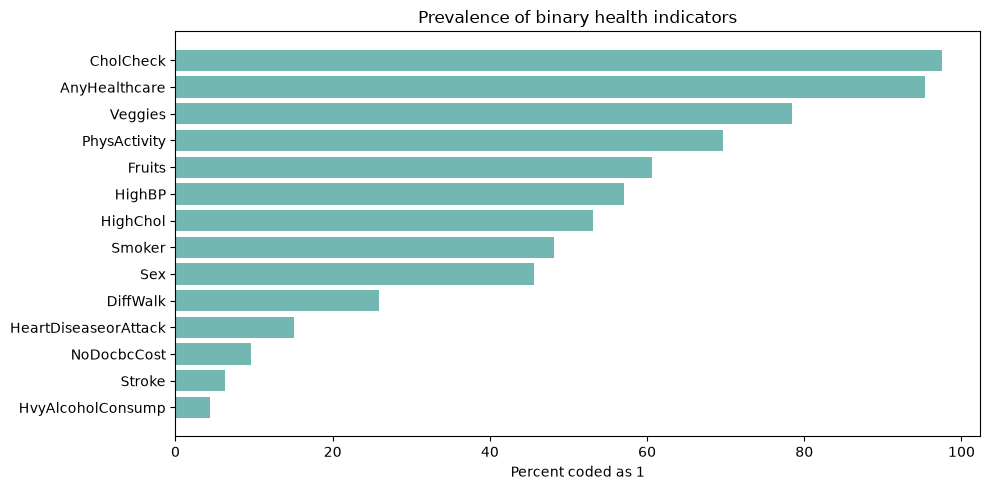

In [8]:
binary_prevalence = (
    diabetes[BINARY_FEATURES].mean().sort_values(ascending=False).mul(100).round(2)
)
display(binary_prevalence.to_frame("prevalence_pct"))

ordered_prevalence = binary_prevalence.sort_values()
plt.figure(figsize=(10, 5))
plt.barh(ordered_prevalence.index, ordered_prevalence.values, color="#72B7B2")
plt.title("Prevalence of binary health indicators")
plt.xlabel("Percent coded as 1")
plt.tight_layout()
plt.show()

**Nhận xét.** Các indicator phổ biến nhất là `CholCheck` (97.48%), `AnyHealthcare` (95.39%) và `Veggies` (78.41%). Các indicator hiếm như `HvyAlcoholConsump` (4.35%) và `Stroke` (6.36%) cần được giữ nhưng model phải xử lý class/feature imbalance ổn định.


---

### 10. Quan hệ feature-target

So sánh target rate theo từng nhóm feature.


BMI         MentHlth         PhysHlth          GenHlth              Age       
                      mean median      mean median      mean median      mean median      mean median
Diabetes_binary                                                                                      
0                27.880183   27.0  3.164929    0.0  3.813045    0.0  2.417020    2.0  7.806272    8.0
1                31.964242   31.0  4.493404    0.0  8.008491    1.0  3.295894    3.0  9.375958   10.0

,feature,value,target_rate,count
33,Age,1.0,0.080247,972
34,Age,2.0,0.101597,1378
35,Age,3.0,0.157472,1994
36,Age,4.0,0.232256,2691
37,Age,5.0,0.309714,3387
38,Age,6.0,0.389311,4472
39,Age,7.0,0.463558,6627
40,Age,8.0,0.505362,8392
41,Age,9.0,0.575408,9873
42,Age,10.0,0.612470,10585


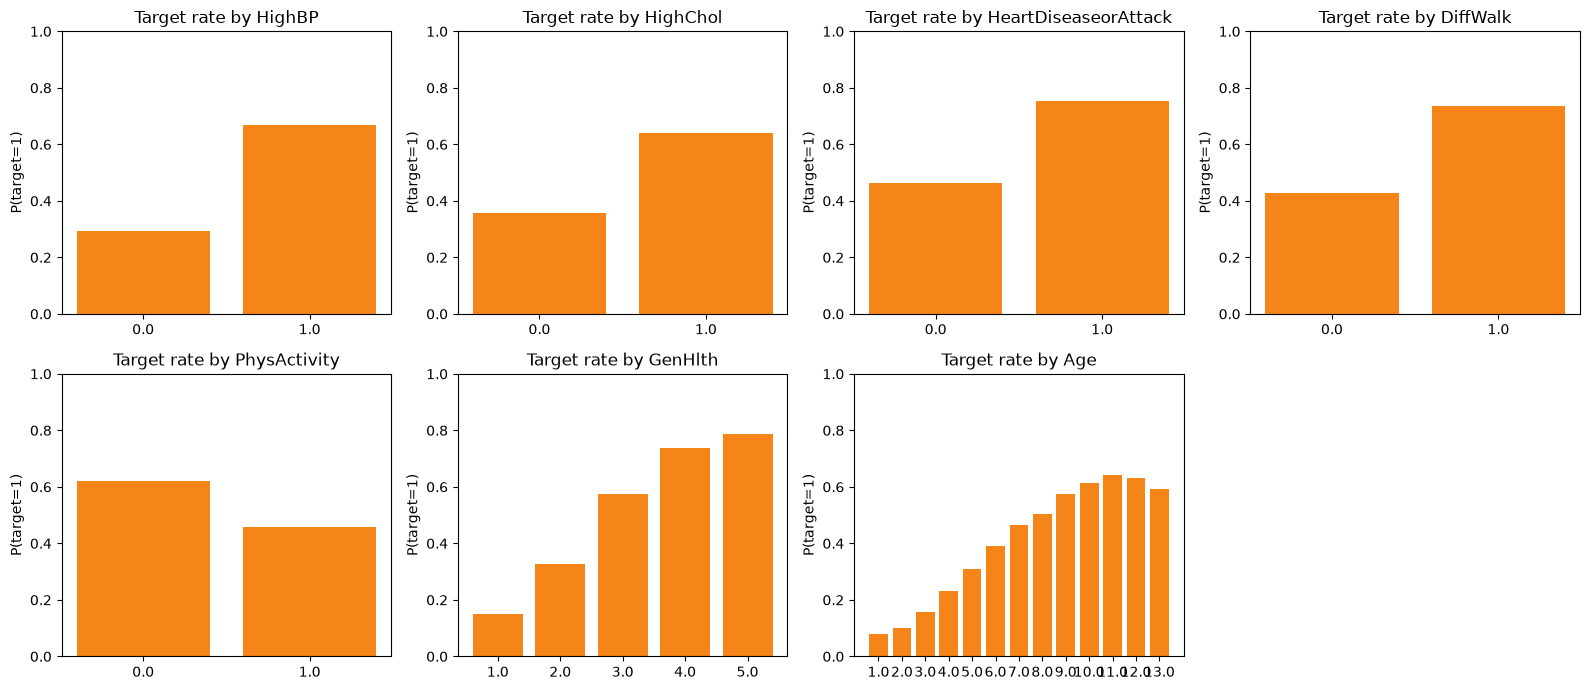

In [9]:
group_summary = diabetes.groupby(DIABETES_TARGET)[
    ["BMI", "MentHlth", "PhysHlth", "GenHlth", "Age"]
].agg(["mean", "median"])
display(group_summary)

rate_rows = []
for col in BINARY_FEATURES + ORDINAL_FEATURES:
    temp = diabetes.groupby(col)[DIABETES_TARGET].agg(["mean", "count"]).reset_index()
    temp["feature"] = col
    temp = temp.rename(columns={col: "value", "mean": "target_rate"})
    rate_rows.append(temp[["feature", "value", "target_rate", "count"]])
target_rates = pd.concat(rate_rows, ignore_index=True)
display(target_rates.sort_values(["feature", "value"]).head(40))

selected = [
    "HighBP",
    "HighChol",
    "HeartDiseaseorAttack",
    "DiffWalk",
    "PhysActivity",
    "GenHlth",
    "Age",
]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for ax, col in zip(axes, selected):
    temp = diabetes.groupby(col)[DIABETES_TARGET].mean().reset_index()
    ax.bar(temp[col].astype(str), temp[DIABETES_TARGET], color="#F58518")
    ax.set_title(f"Target rate by {col}")
    ax.set_ylim(0, 1)
    ax.set_ylabel("P(target=1)")
for ax in axes[len(selected) :]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Nhận xét.** Target rate tăng mạnh khi `HighBP=1` (66.9% so với 29.4%), `HighChol=1` (64.0% so với 35.8%) và `DiffWalk=1` (73.4% so với 42.9%). `PhysActivity=1` lại có target rate thấp hơn (45.9% so với 62.2%). Đây là quan hệ quan sát, không phải kết luận nhân quả.


---

### 11. Outlier và redundancy

Kiểm tra outlier và correlation trước khi modeling.


,feature,min,q1,median,q3,max,iqr_lower,iqr_upper,outlier_count,outlier_pct
0,BMI,12.0,25.0,29.0,33.0,98.0,13.0,45.0,2181,3.16
1,MentHlth,0.0,0.0,0.0,3.0,30.0,-4.5,7.5,10703,15.50
2,PhysHlth,0.0,0.0,0.0,6.0,30.0,-9.0,15.0,10620,15.38


,corr_with_target
GenHlth,0.396571
HighBP,0.372048
BMI,0.285643
HighChol,0.281399
Age,0.274550
DiffWalk,0.267082
Income,-0.212846
HeartDiseaseorAttack,0.207229
PhysHlth,0.206868
Education,-0.158522


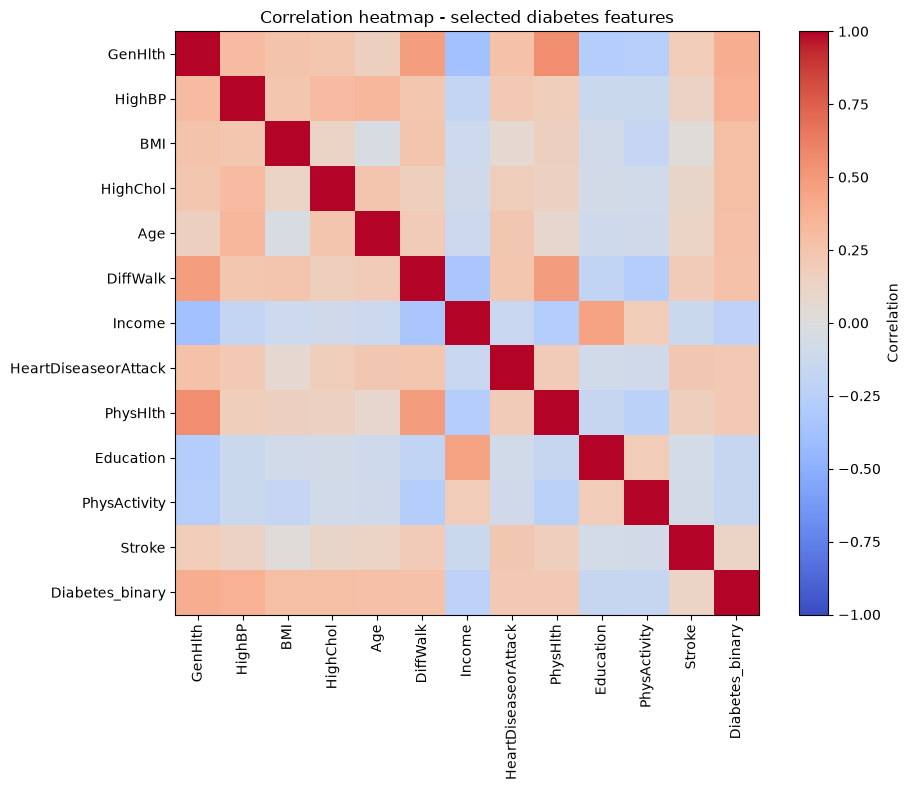

In [10]:
display(iqr_outlier_table(diabetes, ["BMI", "MentHlth", "PhysHlth"]))

corr = diabetes[DIABETES_FEATURES + [DIABETES_TARGET]].corr(numeric_only=True)
target_corr = (
    corr[DIABETES_TARGET]
    .drop(DIABETES_TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(target_corr.to_frame("corr_with_target"))

top_corr_features = target_corr.abs().head(12).index.tolist()
plt.figure(figsize=(10, 8))
plt.imshow(
    diabetes[top_corr_features + [DIABETES_TARGET]].corr(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)
plt.colorbar(label="Correlation")
labels = top_corr_features + [DIABETES_TARGET]
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title("Correlation heatmap - selected diabetes features")
plt.tight_layout()
plt.show()

**Nhận xét.** Correlation cao nhất với target là `GenHlth` (0.397), `HighBP` (0.372), `BMI` (0.286), `HighChol` (0.281) và `Age` (0.275). Không feature nào tương quan tuyệt đối quá cao, nên chưa có dấu hiệu leakage tuyến tính trực tiếp.


---

### 12. Leakage analysis

Kiểm tra target trong X, duplicate, ID-only columns và feature dẫn xuất từ target.


In [11]:
possible_id_cols = [
    c for c in diabetes.columns if c.lower().endswith("_id") or c.lower() == "id"
]
leakage_report = {
    "target_in_features": DIABETES_TARGET in DIABETES_FEATURES,
    "id_like_columns": possible_id_cols,
    "duplicates_after_cleaning": int(diabetes.duplicated().sum()),
    "columns_mathematically_derived_from_target": [],
}
print(json.dumps(leakage_report, indent=2, ensure_ascii=False))

{
  "target_in_features": false,
  "id_like_columns": [],
  "duplicates_after_cleaning": 0,
  "columns_mathematically_derived_from_target": []
}


**Nhận xét.** Leakage report cho thấy `target_in_features=false`, không có ID-like columns và duplicates sau cleaning bằng 0. Feature matrix có thể dùng cho split/modeling.


---

### 13. Biểu diễn dữ liệu

Mỗi record được biểu diễn thành vector số 21 chiều.


In [12]:
sample_raw = diabetes.iloc[[0]]
X_diabetes = diabetes[DIABETES_FEATURES].copy()
y_diabetes = diabetes[DIABETES_TARGET].astype(int).copy()

display_df("One raw record", sample_raw)
print("Feature columns:", DIABETES_FEATURES)
print("One feature vector shape:", X_diabetes.iloc[[0]].shape)
print("Feature matrix shape:", X_diabetes.shape)
print("Target vector shape:", y_diabetes.shape)
display(X_diabetes.iloc[[0]])

One raw record


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0


Feature columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
One feature vector shape: (1, 21)
Feature matrix shape: (69057, 21)
Target vector shape: (69057,)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0


**Nhận xét.** X có shape `(69057, 21)`, nên DL baseline chỉ cần đổi input dimension từ 8 sang 21. Các thành phần còn lại của kiến trúc giảng viên được giữ nguyên.


---

### 14. Preprocessing pipeline

Đóng gói imputation và scaling bằng sklearn Pipeline/ColumnTransformer.


In [13]:
diabetes_numeric_features = DIABETES_FEATURES

diabetes_numeric_preprocess = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

diabetes_preprocessor = ColumnTransformer(
    [
        ("numeric", diabetes_numeric_preprocess, diabetes_numeric_features),
    ],
    remainder="drop",
)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.20,
    random_state=SEED,
    stratify=y_diabetes,
)

X_train_d_ready = diabetes_preprocessor.fit_transform(X_train_d)
X_test_d_ready = diabetes_preprocessor.transform(X_test_d)

print("Train target distribution:")
display(y_train_d.value_counts(normalize=True).sort_index().to_frame("train_pct"))
print("Test target distribution:")
display(y_test_d.value_counts(normalize=True).sort_index().to_frame("test_pct"))

Train target distribution:


,train_pct
Diabetes_binary,
0,0.491773
1,0.508227


Test target distribution:


,test_pct
Diabetes_binary,
0,0.491746
1,0.508254


**Nhận xét.** Train/test split tạo 55,245 dòng train và 13,812 dòng test. Sau preprocessing, cả hai matrix đều có 21 cột và không có NaN/Inf.


---

### 15. Kiểm tra preprocessing

Xác nhận X/y, split và transformed matrix hợp lệ.


In [14]:
assert DIABETES_TARGET not in X_diabetes.columns
assert len(X_diabetes) == len(y_diabetes)
assert X_train_d_ready.shape[0] == len(y_train_d)
assert X_test_d_ready.shape[0] == len(y_test_d)
assert X_train_d_ready.shape[1] == X_test_d_ready.shape[1]

assert_no_nan_inf(X_train_d_ready, "X_train_d_ready")
assert_no_nan_inf(X_test_d_ready, "X_test_d_ready")

phase3_diabetes_summary = {
    "dataset": str(DIABETES_PATH.relative_to(ROOT)),
    "target": DIABETES_TARGET,
    "task": "binary classification",
    "rows_after_cleaning": int(len(diabetes)),
    "feature_count": int(len(DIABETES_FEATURES)),
    "preprocessor": "median imputation + standard scaling",
    "ready_for_modeling_and_packaging": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Teacher/Improved NumPy DL",
    ],
}
print(json.dumps(phase3_diabetes_summary, indent=2, ensure_ascii=False))

X_train_d_ready: shape=(55245, 21), finite_values=OK
X_test_d_ready: shape=(13812, 21), finite_values=OK
{
  "dataset": "datasets\\diabetes\\diabetes.csv",
  "target": "Diabetes_binary",
  "task": "binary classification",
  "rows_after_cleaning": 69057,
  "feature_count": 21,
  "preprocessor": "median imputation + standard scaling",
  "ready_for_modeling_and_packaging": [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "Teacher/Improved NumPy DL"
  ]
}


---

### 16. Baseline và 5 mô hình ML

Huấn luyện 5 mô hình chính:

1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. SVM


In [15]:
def safe_roc_auc(y_true, score):
    try:
        return roc_auc_score(y_true, score)
    except Exception:
        return np.nan


def classification_score_from_estimator(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def classification_metrics_row(name, y_true, y_pred, score):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": safe_roc_auc(y_true, score),
    }


def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))


def binary_cross_entropy(y_true, y_prob, sample_weight=None, eps=1e-8):
    y_true = y_true.reshape(-1, 1)
    y_prob = np.clip(y_prob, eps, 1 - eps)
    per_sample = -(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    if sample_weight is None:
        return float(np.mean(per_sample))
    weights = sample_weight.reshape(-1, 1)
    return float(np.sum(per_sample * weights) / np.sum(weights))


def teacher_forward_binary(X, params):
    z1 = X @ params["W1"] + params["b1"]
    h1 = relu(z1)
    z2 = h1 @ params["W2"] + params["b2"]
    h2 = relu(z2)
    z3 = h2 @ params["W3"] + params["b3"]
    y_hat = sigmoid(z3)
    cache = {"X": X, "z1": z1, "h1": h1, "z2": z2, "h2": h2, "z3": z3, "y_hat": y_hat}
    return y_hat, cache


def train_teacher_binary_dnn(
    X_train, y_train, input_dim, epochs=1000, learning_rate=0.01, seed=42
):
    rng = np.random.default_rng(seed)
    y_train = y_train.reshape(-1, 1)
    params = {
        "W1": rng.normal(size=(input_dim, 16)) * np.sqrt(2.0 / input_dim),
        "b1": np.zeros((1, 16)),
        "W2": rng.normal(size=(16, 8)) * np.sqrt(2.0 / 16),
        "b2": np.zeros((1, 8)),
        "W3": rng.normal(size=(8, 1)) * np.sqrt(2.0 / 8),
        "b3": np.zeros((1, 1)),
    }
    losses = []
    for epoch in range(epochs):
        y_hat, cache = teacher_forward_binary(X_train, params)
        losses.append(binary_cross_entropy(y_train, y_hat))

        n = len(X_train)
        dz3 = (y_hat - y_train) / n
        dW3 = cache["h2"].T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)
        dh2 = dz3 @ params["W3"].T
        dz2 = dh2 * relu_derivative(cache["z2"])
        dW2 = cache["h1"].T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        dh1 = dz2 @ params["W2"].T
        dz1 = dh1 * relu_derivative(cache["z1"])
        dW1 = cache["X"].T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        params["W3"] -= learning_rate * dW3
        params["b3"] -= learning_rate * db3
        params["W2"] -= learning_rate * dW2
        params["b2"] -= learning_rate * db2
        params["W1"] -= learning_rate * dW1
        params["b1"] -= learning_rate * db1
    return params, losses


def improved_forward_binary(X, params):
    z1 = X @ params["W1"] + params["b1"]
    h1 = relu(z1)
    z2 = h1 @ params["W2"] + params["b2"]
    h2 = relu(z2)
    z3 = h2 @ params["W3"] + params["b3"]
    y_hat = sigmoid(z3)
    cache = {"X": X, "z1": z1, "h1": h1, "z2": z2, "h2": h2, "z3": z3, "y_hat": y_hat}
    return y_hat, cache


def train_improved_binary_dnn(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden=(64, 32),
    epochs=300,
    learning_rate=0.01,
    batch_size=512,
    l2=1e-4,
    class_weight=None,
    patience=25,
    seed=42,
):
    rng = np.random.default_rng(seed)
    input_dim = X_train.shape[1]
    h1, h2 = hidden
    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    params = {
        "W1": rng.normal(size=(input_dim, h1)) * np.sqrt(2.0 / input_dim),
        "b1": np.zeros((1, h1)),
        "W2": rng.normal(size=(h1, h2)) * np.sqrt(2.0 / h1),
        "b2": np.zeros((1, h2)),
        "W3": rng.normal(size=(h2, 1)) * np.sqrt(2.0 / h2),
        "b3": np.zeros((1, 1)),
    }
    sample_weight = None
    if class_weight is not None:
        sample_weight = np.array(
            [class_weight[int(v)] for v in y_train.ravel()], dtype=float
        )

    history = {"train_loss": [], "val_loss": []}
    best_params = {k: v.copy() for k, v in params.items()}
    best_val = np.inf
    wait = 0

    for epoch in range(epochs):
        indices = rng.permutation(len(X_train))
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start : start + batch_size]
            xb = X_train[batch_idx]
            yb = y_train[batch_idx]
            wb = sample_weight[batch_idx] if sample_weight is not None else None
            y_hat, cache = improved_forward_binary(xb, params)
            if wb is None:
                dz3 = (y_hat - yb) / len(xb)
            else:
                dz3 = (y_hat - yb) * wb.reshape(-1, 1) / np.sum(wb)

            dW3 = cache["h2"].T @ dz3 + l2 * params["W3"] / len(xb)
            db3 = np.sum(dz3, axis=0, keepdims=True)
            dh2 = dz3 @ params["W3"].T
            dz2 = dh2 * relu_derivative(cache["z2"])
            dW2 = cache["h1"].T @ dz2 + l2 * params["W2"] / len(xb)
            db2 = np.sum(dz2, axis=0, keepdims=True)
            dh1 = dz2 @ params["W2"].T
            dz1 = dh1 * relu_derivative(cache["z1"])
            dW1 = cache["X"].T @ dz1 + l2 * params["W1"] / len(xb)
            db1 = np.sum(dz1, axis=0, keepdims=True)

            params["W3"] -= learning_rate * dW3
            params["b3"] -= learning_rate * db3
            params["W2"] -= learning_rate * dW2
            params["b2"] -= learning_rate * db2
            params["W1"] -= learning_rate * dW1
            params["b1"] -= learning_rate * db1

        train_prob, _ = improved_forward_binary(X_train, params)
        val_prob, _ = improved_forward_binary(X_val, params)
        train_loss = binary_cross_entropy(
            y_train, train_prob, sample_weight=sample_weight
        )
        val_loss = binary_cross_entropy(y_val, val_prob)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_params = {k: v.copy() for k, v in params.items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    return best_params, history


def tune_threshold_by_f1(y_true, prob):
    rows = []
    for threshold in np.linspace(0.2, 0.8, 61):
        pred = (prob >= threshold).astype(int)
        rows.append(
            {"threshold": threshold, "f1": f1_score(y_true, pred, zero_division=0)}
        )
    table = pd.DataFrame(rows)
    best = table.sort_values("f1", ascending=False).iloc[0]
    return float(best["threshold"]), table


diabetes_reference_baseline = DummyClassifier(strategy="most_frequent")
diabetes_reference_baseline.fit(X_train_d, y_train_d)
baseline_pred_d = diabetes_reference_baseline.predict(X_test_d)
baseline_score_d = baseline_pred_d
diabetes_baseline_metrics = pd.DataFrame(
    [
        classification_metrics_row(
            "Reference Baseline - Most Frequent",
            y_test_d,
            baseline_pred_d,
            baseline_score_d,
        )
    ]
)
display(diabetes_baseline_metrics.round(4))

diabetes_ml_models = {
    "Logistic Regression": Pipeline(
        [
            ("preprocessor", clone(diabetes_preprocessor)),
            ("model", LogisticRegression(max_iter=1000, random_state=SEED)),
        ]
    ),
    "KNN": Pipeline(
        [
            ("preprocessor", clone(diabetes_preprocessor)),
            (
                "model",
                KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1),
            ),
        ]
    ),
    "Decision Tree": Pipeline(
        [
            ("preprocessor", clone(diabetes_preprocessor)),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=10, min_samples_leaf=40, random_state=SEED
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("preprocessor", clone(diabetes_preprocessor)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=180, min_samples_leaf=10, random_state=SEED, n_jobs=-1
                ),
            ),
        ]
    ),
    "SVM": Pipeline(
        [
            ("preprocessor", clone(diabetes_preprocessor)),
            ("model", LinearSVC(C=1.0, max_iter=6000, random_state=SEED)),
        ]
    ),
}

diabetes_ml_rows = []
diabetes_overfit_rows = []
fitted_diabetes_ml_models = {}
for name, model in diabetes_ml_models.items():
    model.fit(X_train_d, y_train_d)
    fitted_diabetes_ml_models[name] = model
    y_pred = model.predict(X_test_d)
    y_score = classification_score_from_estimator(model, X_test_d)
    diabetes_ml_rows.append(classification_metrics_row(name, y_test_d, y_pred, y_score))

    train_pred = model.predict(X_train_d)
    diabetes_overfit_rows.append(
        {
            "Model": name,
            "Train F1": f1_score(y_train_d, train_pred, zero_division=0),
            "Test F1": f1_score(y_test_d, y_pred, zero_division=0),
            "Gap": f1_score(y_train_d, train_pred, zero_division=0)
            - f1_score(y_test_d, y_pred, zero_division=0),
        }
    )

diabetes_ml_results = (
    pd.DataFrame(diabetes_ml_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)
diabetes_overfit_table = pd.DataFrame(diabetes_overfit_rows).sort_values(
    "Gap", ascending=False
)
display(diabetes_ml_results.round(4))
display(diabetes_overfit_table.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Reference Baseline - Most Frequent,0.5083,0.5083,1.0,0.674,0.5


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.7446,0.7270,0.7964,0.7602,0.8208
1,SVM,0.7438,0.7341,0.7775,0.7552,0.8171
2,Logistic Regression,0.7450,0.7380,0.7726,0.7549,0.8174
3,Decision Tree,0.7344,0.7179,0.7866,0.7507,0.8059
4,KNN,0.7228,0.7089,0.7715,0.7389,0.7856


,Model,Train F1,Test F1,Gap
1,KNN,0.9953,0.7389,0.2564
3,Random Forest,0.7969,0.7602,0.0367
2,Decision Tree,0.7680,0.7507,0.0173
4,SVM,0.7551,0.7552,-0.0001
0,Logistic Regression,0.7541,0.7549,-0.0008


**Nhận xét.** Random Forest đạt Test F1 = 0.760 và ROC-AUC = 0.821, là mô hình ML mạnh nhất theo F1. KNN thấp hơn (F1 = 0.739), phù hợp với đặc điểm dữ liệu có nhiều ordinal/binary features.


---

### 17. DL baseline theo mã mẫu giảng viên

Baseline giữ NumPy-only, kiến trúc `input -> 16 -> 8 -> 1`, ReLU/ReLU/Sigmoid, BCE, full-batch gradient descent, learning rate `0.01` và `1000` epochs.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Teacher DL Baseline,0.7177,0.7088,0.7546,0.731,0.7804


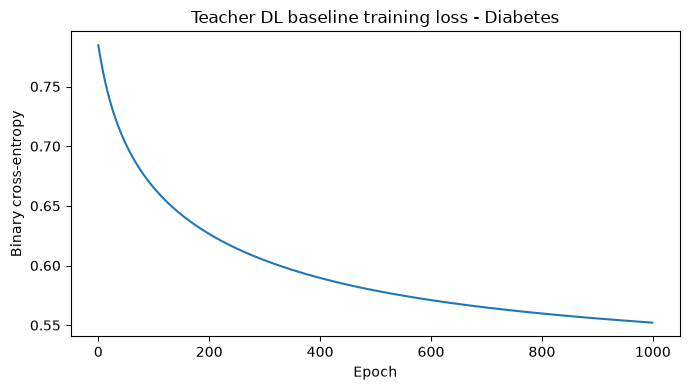

In [16]:
X_train_d_dense = to_dense_array(X_train_d_ready)
X_test_d_dense = to_dense_array(X_test_d_ready)
y_train_d_np = y_train_d.to_numpy().astype(int)
y_test_d_np = y_test_d.to_numpy().astype(int)

teacher_diabetes_params, teacher_diabetes_loss = train_teacher_binary_dnn(
    X_train_d_dense,
    y_train_d_np,
    input_dim=X_train_d_dense.shape[1],
    epochs=1000,
    learning_rate=0.01,
    seed=SEED,
)
teacher_diabetes_prob, _ = teacher_forward_binary(
    X_test_d_dense, teacher_diabetes_params
)
teacher_diabetes_prob = teacher_diabetes_prob.ravel()
teacher_diabetes_pred = (teacher_diabetes_prob >= 0.5).astype(int)
teacher_diabetes_metrics = pd.DataFrame(
    [
        classification_metrics_row(
            "Teacher DL Baseline",
            y_test_d_np,
            teacher_diabetes_pred,
            teacher_diabetes_prob,
        )
    ]
)
display(teacher_diabetes_metrics.round(4))

if HAS_MATPLOTLIB:
    plt.figure(figsize=(7, 4))
    plt.plot(teacher_diabetes_loss)
    plt.title("Teacher DL baseline training loss - Diabetes")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.tight_layout()
    plt.show()

**Nhận xét.** DL baseline đạt F1 = 0.731 và ROC-AUC = 0.780. Kết quả này thấp hơn các ML tốt nhất, cho thấy baseline gốc còn hạn chế trên bộ CDC 21 feature.


---

### 18. Improved DNN

Improved DNN thêm validation split, hidden layers lớn hơn, mini-batch, L2 regularization, early stopping và threshold tuning.


Selected validation threshold: 0.3


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Improved DNN,0.7208,0.6609,0.9256,0.7712,0.8192


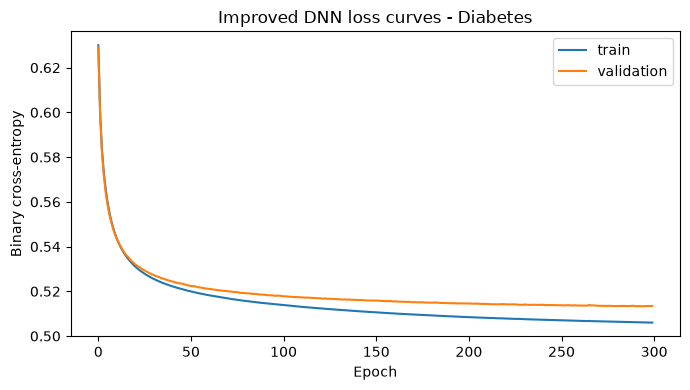

In [17]:
X_d_train_nn, X_d_val_nn, y_d_train_nn, y_d_val_nn = train_test_split(
    X_train_d_dense,
    y_train_d_np,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_d_np,
)

improved_diabetes_params, improved_diabetes_history = train_improved_binary_dnn(
    X_d_train_nn,
    y_d_train_nn,
    X_d_val_nn,
    y_d_val_nn,
    hidden=(32, 16),
    epochs=300,
    learning_rate=0.01,
    batch_size=512,
    l2=1e-4,
    class_weight=None,
    patience=30,
    seed=SEED,
)

val_prob_d, _ = improved_forward_binary(X_d_val_nn, improved_diabetes_params)
val_prob_d = val_prob_d.ravel()
best_threshold_d, threshold_table_d = tune_threshold_by_f1(y_d_val_nn, val_prob_d)

improved_diabetes_prob, _ = improved_forward_binary(
    X_test_d_dense, improved_diabetes_params
)
improved_diabetes_prob = improved_diabetes_prob.ravel()
improved_diabetes_pred = (improved_diabetes_prob >= best_threshold_d).astype(int)
improved_diabetes_row = classification_metrics_row(
    "Improved DNN", y_test_d_np, improved_diabetes_pred, improved_diabetes_prob
)

print("Selected validation threshold:", round(best_threshold_d, 3))
display(pd.DataFrame([improved_diabetes_row]).round(4))

if HAS_MATPLOTLIB:
    plt.figure(figsize=(7, 4))
    plt.plot(improved_diabetes_history["train_loss"], label="train")
    plt.plot(improved_diabetes_history["val_loss"], label="validation")
    plt.title("Improved DNN loss curves - Diabetes")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Nhận xét.** Improved DNN đạt Recall = 0.926 và F1 = 0.771, tăng rõ so với DL baseline F1 = 0.731. Threshold tuning giúp model ưu tiên bắt class `1`, đổi lại Precision giảm còn 0.661.


---

### 19. So sánh DL

So sánh DL baseline của giảng viên với Improved DNN.


In [18]:
diabetes_dl_comparison = pd.concat(
    [teacher_diabetes_metrics, pd.DataFrame([improved_diabetes_row])],
    ignore_index=True,
)
display(diabetes_dl_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Teacher DL Baseline,0.7177,0.7088,0.7546,0.7310,0.7804
1,Improved DNN,0.7208,0.6609,0.9256,0.7712,0.8192


---

### 20. So sánh 6 mô hình cuối

Bảng cuối gồm 5 mô hình ML và Improved DNN.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,Improved DNN,0.7208,0.6609,0.9256,0.7712,0.8192
0,Random Forest,0.7446,0.7270,0.7964,0.7602,0.8208
1,SVM,0.7438,0.7341,0.7775,0.7552,0.8171
2,Logistic Regression,0.7450,0.7380,0.7726,0.7549,0.8174
3,Decision Tree,0.7344,0.7179,0.7866,0.7507,0.8059
4,KNN,0.7228,0.7089,0.7715,0.7389,0.7856


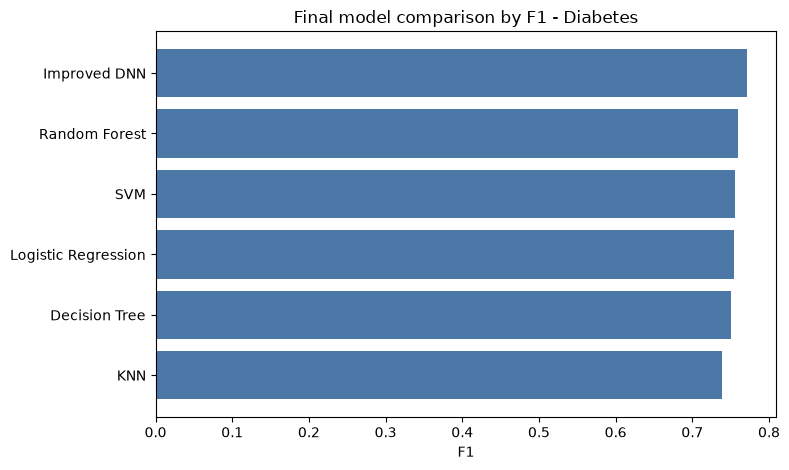

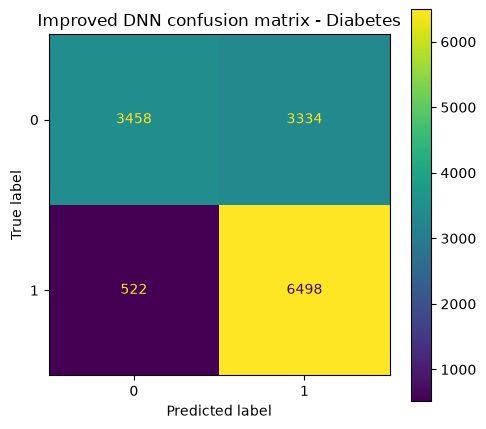

In [19]:
final_diabetes_comparison = pd.concat(
    [diabetes_ml_results, pd.DataFrame([improved_diabetes_row])],
    ignore_index=True,
)
final_diabetes_comparison = final_diabetes_comparison[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]
assert len(final_diabetes_comparison) == 6
assert "Teacher DL Baseline" not in final_diabetes_comparison["Model"].tolist()
display(final_diabetes_comparison.sort_values("F1", ascending=False).round(4))

if HAS_MATPLOTLIB:
    chart_df = final_diabetes_comparison.sort_values("F1")
    plt.figure(figsize=(8, 4.8))
    plt.barh(chart_df["Model"], chart_df["F1"], color="#4C78A8")
    plt.xlabel("F1")
    plt.title("Final model comparison by F1 - Diabetes")
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(y_test_d_np, improved_diabetes_pred)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=ax, values_format="d")
    ax.set_title("Improved DNN confusion matrix - Diabetes")
    plt.tight_layout()
    plt.show()

**Nhận xét.** Improved DNN là model tốt nhất theo F1 (0.771), nhỉnh hơn Random Forest (0.760). Tuy vậy Random Forest có ROC-AUC cao hơn nhẹ (0.821 so với 0.819), nên DL thắng theo F1 nhưng không áp đảo mọi metric.


In [20]:
best_diabetes_row = final_diabetes_comparison.sort_values("F1", ascending=False).iloc[0]
print("Best final diabetes model:", best_diabetes_row["Model"])
print("Primary metric F1:", round(float(best_diabetes_row["F1"]), 4))
print(
    "Did Improved DNN beat all classical ML by F1?:",
    bool(best_diabetes_row["Model"] == "Improved DNN"),
)

Best final diabetes model: Improved DNN
Primary metric F1: 0.7712
Did Improved DNN beat all classical ML by F1?: True


---

### 21. Đóng gói pipeline

Lưu model tốt nhất, preprocessor, metadata, feature schema, demo input và demo prediction. Artifact được load lại để kiểm tra inference.


In [21]:
PIPELINE_ARTIFACT_DIR = ROOT / "pipeline" / "diabetes"
PIPELINE_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    return value


def write_json(path, payload):
    path.write_text(
        json.dumps(json_safe(payload), indent=2, ensure_ascii=False), encoding="utf-8"
    )


def relative_path(path):
    return str(Path(path).relative_to(ROOT)).replace("\\", "/")


def metrics_from_row(row, columns):
    return {col: json_safe(row[col]) for col in columns}


DIABETES_METRIC_COLUMNS = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
assert len(final_diabetes_comparison) == 6
assert "Teacher DL Baseline" not in final_diabetes_comparison["Model"].tolist()

best_diabetes_row = final_diabetes_comparison.sort_values("F1", ascending=False).iloc[0]
selected_diabetes_model = str(best_diabetes_row["Model"])

model_path = PIPELINE_ARTIFACT_DIR / (
    "model.npz" if selected_diabetes_model == "Improved DNN" else "model.joblib"
)
preprocessor_path = PIPELINE_ARTIFACT_DIR / "preprocessor.joblib"
metadata_path = PIPELINE_ARTIFACT_DIR / "metadata.json"
schema_path = PIPELINE_ARTIFACT_DIR / "feature_schema.json"
demo_input_path = PIPELINE_ARTIFACT_DIR / "demo_input.json"
demo_prediction_path = PIPELINE_ARTIFACT_DIR / "demo_prediction.json"
final_table_path = PIPELINE_ARTIFACT_DIR / "final_comparison.csv"
dl_table_path = PIPELINE_ARTIFACT_DIR / "dl_comparison.csv"

if selected_diabetes_model == "Improved DNN":
    np.savez(model_path, **improved_diabetes_params)
    joblib.dump(diabetes_preprocessor, preprocessor_path)
    model_format = "NumPy DNN weights (.npz) + joblib ColumnTransformer"
    decision_threshold = float(best_threshold_d)
else:
    selected_pipeline = fitted_diabetes_ml_models[selected_diabetes_model]
    joblib.dump(selected_pipeline, model_path)
    joblib.dump(
        selected_pipeline.named_steps.get("preprocessor", diabetes_preprocessor),
        preprocessor_path,
    )
    model_format = "joblib sklearn Pipeline"
    decision_threshold = None

final_diabetes_comparison.to_csv(final_table_path, index=False)
diabetes_dl_comparison.to_csv(dl_table_path, index=False)

diabetes_feature_descriptions = {
    "HighBP": "High blood pressure survey indicator.",
    "HighChol": "High cholesterol survey indicator.",
    "CholCheck": "Cholesterol check in recent years.",
    "BMI": "Body mass index.",
    "Smoker": "Smoked at least 100 cigarettes in lifetime.",
    "Stroke": "Stroke history indicator.",
    "HeartDiseaseorAttack": "Coronary heart disease or myocardial infarction history.",
    "PhysActivity": "Physical activity in past 30 days, excluding job activity.",
    "Fruits": "Consumes fruit at least once per day.",
    "Veggies": "Consumes vegetables at least once per day.",
    "HvyAlcoholConsump": "Heavy alcohol consumption indicator.",
    "AnyHealthcare": "Has any healthcare coverage.",
    "NoDocbcCost": "Could not see a doctor because of cost.",
    "GenHlth": "General health ordinal survey code.",
    "MentHlth": "Days of poor mental health in the last 30 days.",
    "PhysHlth": "Days of poor physical health in the last 30 days.",
    "DiffWalk": "Difficulty walking or climbing stairs.",
    "Sex": "Sex survey code from the source dataset.",
    "Age": "Age group ordinal code from the source dataset.",
    "Education": "Education-level ordinal code from the source dataset.",
    "Income": "Income-level ordinal code from the source dataset.",
}

diabetes_feature_schema = {
    "task_name": "Diabetes Classification",
    "target": DIABETES_TARGET,
    "prediction_time_input": "One row with the CDC/BRFSS health-indicator features in feature_order.",
    "feature_order": DIABETES_FEATURES,
    "features": [],
}
for col in DIABETES_FEATURES:
    if col in BINARY_FEATURES:
        allowed = "0 or 1 survey indicator."
        unit = None
    elif col == "BMI":
        allowed = "Positive numeric body-mass-index value."
        unit = "kg/m2"
    elif col in COUNT_FEATURES:
        allowed = "Integer count from 0 to 30."
        unit = "days"
    elif col == "GenHlth":
        allowed = "Ordinal code 1 to 5."
        unit = None
    elif col == "Age":
        allowed = "Ordinal age-group code 1 to 13."
        unit = None
    elif col == "Education":
        allowed = "Ordinal education code 1 to 6."
        unit = None
    elif col == "Income":
        allowed = "Ordinal income code 1 to 8."
        unit = None
    else:
        allowed = "Numeric value following CDC/BRFSS source coding."
        unit = None
    diabetes_feature_schema["features"].append(
        {
            "name": col,
            "type": "number",
            "required": True,
            "allowed_or_category_notes": allowed,
            "unit": unit,
            "description": diabetes_feature_descriptions.get(
                col, "CDC/BRFSS model input feature."
            ),
        }
    )

diabetes_metadata = {
    "task_name": "Diabetes Classification",
    "task_type": "binary_classification",
    "dataset_name": "CDC Diabetes Health Indicators / BRFSS 2015 balanced",
    "dataset_path": relative_path(DIABETES_PATH),
    "target": DIABETES_TARGET,
    "selected_model": selected_diabetes_model,
    "selection_metric": "F1",
    "metrics": metrics_from_row(best_diabetes_row, DIABETES_METRIC_COLUMNS),
    "feature_count": int(len(DIABETES_FEATURES)),
    "transformed_feature_count": int(X_train_d_ready.shape[1]),
    "training_date": datetime.now(timezone.utc).replace(microsecond=0).isoformat(),
    "preprocessing_summary": "Median imputation and StandardScaler fitted on the training split only.",
    "target_transformation": None,
    "model_format": model_format,
    "model_file": relative_path(model_path),
    "preprocessor_file": relative_path(preprocessor_path),
    "decision_threshold": decision_threshold,
    "notes": [
        "Exact duplicate rows are removed before train/test split.",
        "Teacher DL baseline is evaluated separately and is not included in the final six-model table.",
    ],
}

demo_input = {col: json_safe(X_diabetes.iloc[0][col]) for col in DIABETES_FEATURES}
assert DIABETES_TARGET not in demo_input

write_json(metadata_path, diabetes_metadata)
write_json(schema_path, diabetes_feature_schema)
write_json(demo_input_path, demo_input)

demo_df = pd.DataFrame([demo_input], columns=DIABETES_FEATURES)
if selected_diabetes_model == "Improved DNN":
    loaded_preprocessor = joblib.load(preprocessor_path)
    demo_ready = to_dense_array(loaded_preprocessor.transform(demo_df))
    with np.load(model_path) as loaded:
        loaded_params = {key: loaded[key] for key in loaded.files}
    demo_prob, _ = improved_forward_binary(demo_ready, loaded_params)
    probability = float(demo_prob.ravel()[0])
    demo_prediction = {
        "model": selected_diabetes_model,
        "probability_class_1": probability,
        "predicted_class": int(probability >= decision_threshold),
        "threshold": decision_threshold,
    }
else:
    loaded_model = joblib.load(model_path)
    demo_prediction = {
        "model": selected_diabetes_model,
        "predicted_class": int(loaded_model.predict(demo_df)[0]),
    }
    if hasattr(loaded_model, "predict_proba"):
        demo_prediction["probability_class_1"] = float(
            loaded_model.predict_proba(demo_df)[:, 1][0]
        )
    elif hasattr(loaded_model, "decision_function"):
        demo_prediction["decision_score"] = float(
            loaded_model.decision_function(demo_df)[0]
        )

write_json(demo_prediction_path, demo_prediction)

for json_path in [metadata_path, schema_path, demo_input_path, demo_prediction_path]:
    json.loads(json_path.read_text(encoding="utf-8"))
for path in [
    model_path,
    preprocessor_path,
    metadata_path,
    schema_path,
    demo_input_path,
    demo_prediction_path,
    final_table_path,
    dl_table_path,
]:
    assert path.exists(), f"Missing artifact: {path}"

display(pd.DataFrame([demo_prediction]))
print("Saved diabetes artifacts:")
for path in sorted(PIPELINE_ARTIFACT_DIR.iterdir()):
    print("-", relative_path(path))

,model,probability_class_1,predicted_class,threshold
0,Improved DNN,0.300158,1,0.3


Saved diabetes artifacts:
- pipeline/diabetes/demo_input.json
- pipeline/diabetes/demo_prediction.json
- pipeline/diabetes/dl_comparison.csv
- pipeline/diabetes/feature_schema.json
- pipeline/diabetes/final_comparison.csv
- pipeline/diabetes/metadata.json
- pipeline/diabetes/model.npz
- pipeline/diabetes/preprocessor.joblib
